In [1]:
!pip install shap lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


/tmp/ipykernel_7949/1515069405.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_7949/1515069405.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

✅ Model trained

⏳ Computing SHAP values (may take 1-2 min)...


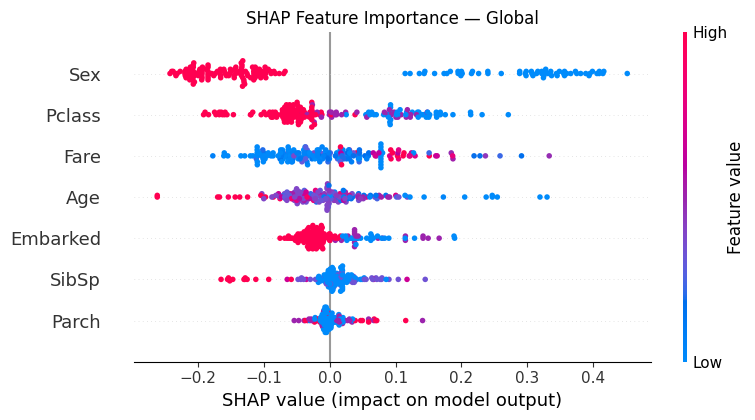

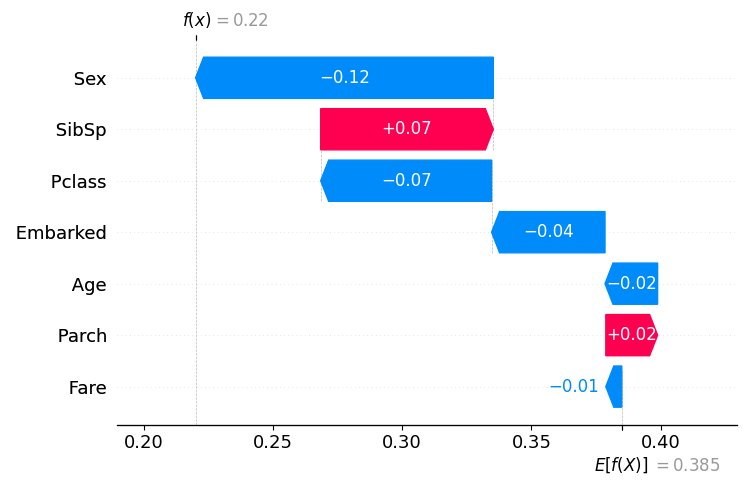


Passenger #0: DIED


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


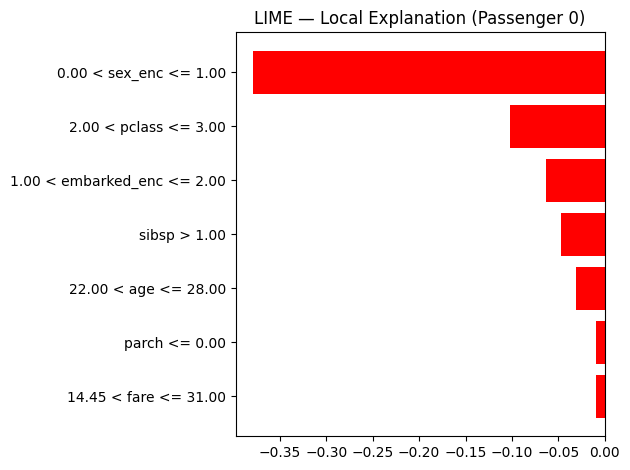



🔍 BIAS ANALYSIS

📊 By Sex:
           actual_survival_rate  predicted_survival_rate  count
sex_label                                                      
female                    0.738                    0.754     61
male                      0.203                    0.136    118

📊 By Passenger Class:
        actual_survival_rate  predicted_survival_rate  count
pclass                                                      
1                      0.556                    0.556     45
2                      0.588                    0.529     34
3                      0.240                    0.190    100


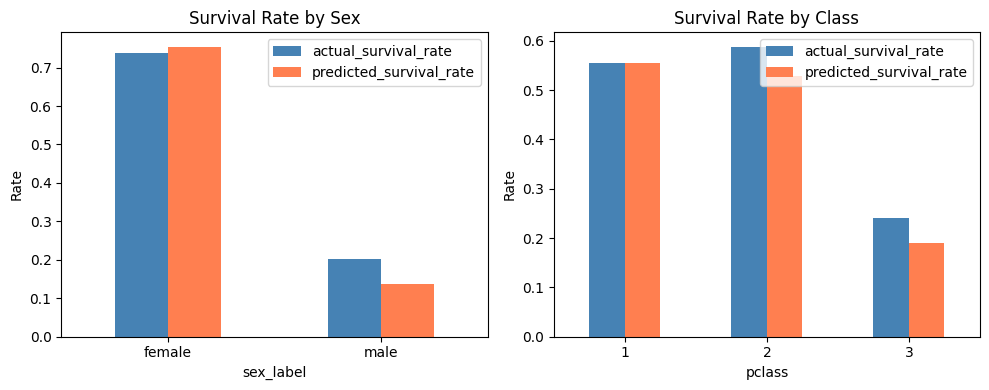


✅ Task 4 complete! Bias analysis shows model replicates historical bias.
Write recommendations in your report.


In [2]:
!pip install shap lime -q

import shap
import lime
import lime.lime_tabular
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# --- Rebuild model from Task 1 ---
df = sns.load_dataset('titanic')
df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']].copy()
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna('S', inplace=True)
df['sex_enc']      = LabelEncoder().fit_transform(df['sex'])
df['embarked_enc'] = LabelEncoder().fit_transform(df['embarked'])

features = ['pclass','sex_enc','age','sibsp','parch','fare','embarked_enc']
X = df[features]
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("✅ Model trained")

# --- SHAP Analysis ---
print("\n⏳ Computing SHAP values (may take 1-2 min)...")
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Global feature importance
plt.figure(figsize=(9,5))
shap.summary_plot(shap_values[:,:,1], X_test,
                  feature_names=['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked'],
                  show=False)
plt.title("SHAP Feature Importance — Global")
plt.tight_layout()
plt.savefig('task4_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# Local explanation (single passenger)
idx = 0
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],
    shap_values[idx,:,1],
    features=X_test.iloc[idx],
    feature_names=['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked'],
    show=True
)
print(f"\nPassenger #{idx}: {'SURVIVED' if y_test.iloc[idx]==1 else 'DIED'}")

# --- LIME Local Explanation ---
lime_exp = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, feature_names=features,
    class_names=['Died','Survived'], mode='classification')
lime_instance = lime_exp.explain_instance(
    X_test.iloc[0].values, rf.predict_proba, num_features=7)
lime_instance.as_pyplot_figure()
plt.title("LIME — Local Explanation (Passenger 0)")
plt.tight_layout()
plt.savefig('task4_lime.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Bias Analysis ---
print("\n\n🔍 BIAS ANALYSIS")
print("="*50)

df_test = X_test.copy()
df_test['survived_actual']    = y_test.values
df_test['survived_predicted'] = rf.predict(X_test)
df_test['sex_label']          = df['sex'].iloc[X_test.index].values

# Bias by sex
print("\n📊 By Sex:")
sex_bias = df_test.groupby('sex_label').agg(
    actual_survival_rate=('survived_actual','mean'),
    predicted_survival_rate=('survived_predicted','mean'),
    count=('survived_actual','count')
).round(3)
print(sex_bias)

# Bias by class
print("\n📊 By Passenger Class:")
class_bias = df_test.groupby('pclass').agg(
    actual_survival_rate=('survived_actual','mean'),
    predicted_survival_rate=('survived_predicted','mean'),
    count=('survived_actual','count')
).round(3)
print(class_bias)

# Visualize bias
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
sex_bias[['actual_survival_rate','predicted_survival_rate']].plot(
    kind='bar', ax=ax1, color=['steelblue','coral'], rot=0)
ax1.set_title('Survival Rate by Sex')
ax1.set_ylabel('Rate')

class_bias[['actual_survival_rate','predicted_survival_rate']].plot(
    kind='bar', ax=ax2, color=['steelblue','coral'], rot=0)
ax2.set_title('Survival Rate by Class')
ax2.set_ylabel('Rate')

plt.tight_layout()
plt.savefig('task4_bias_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ Task 4 complete! Bias analysis shows model replicates historical bias.")
print("Write recommendations in your report.")